# HDF5 Conversion — 20X_DropDown

Converts each `5x.mp4` / `20x.mp4` video in the numbered `20X_DropDown/*` subfolders into its own
224×224 HDF5 file (`frame_i_x`: BGR uint8 frame, `frame_i_y`: `[x_mm, y_mm, z_mm]` float32 motor
position), following the same HDF5-building convention as
`/Users/mayanksengupta/Desktop/AutoNanoChem/current.ipynb`.

**Position alignment** (each subfolder's `test*_frames.csv` logs the whole session; the two videos
are clips taken from within it):
- `5x.mp4`  — aligned to the **start** of the CSV: frame `i` ↔ CSV row `i`.
- `20x.mp4` — aligned to the **end** of the CSV: frame `i` ↔ CSV row `len(csv) - len(video) + i`.

Run this notebook with its own directory (`20X_DropDown/`) as the working directory.

### Imports

In [1]:
import cv2
import h5py
import numpy as np
import pandas as pd
import tempfile
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import mediapy as media

IMG_SIZE = 224
DROPDOWN_DIR = Path.cwd().parent / '20X_DropDown' if Path.cwd().name == 'data_construction' else Path('20X_DropDown')


def interpolate_invalid(arr, invalid_val=0):
    """Linearly interpolate over NaN / invalid_val entries (position=0 mm never occurs in this
    workspace, so it's used as the sentinel for 'no reading yet', same as current.ipynb)."""
    arr = arr.copy().astype(float)
    invalid = np.isnan(arr) | (arr == invalid_val)
    idx = np.arange(len(arr))
    if invalid.all():
        return arr
    arr[invalid] = np.interp(idx[invalid], idx[~invalid], arr[~invalid])
    return arr


def create_video_from_frames(frames, fps=15):
    """Displays a list of BGR uint8 numpy arrays as an HTML5 video."""
    h, w = frames[0].shape[:2]
    tmp = tempfile.NamedTemporaryFile(suffix='.mp4', delete=False)
    tmp.close()

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(tmp.name, fourcc, fps, (w, h))
    for frame in frames:
        out.write(frame)
    out.release()

    video = media.read_video(tmp.name)
    media.show_video(video, fps=fps, width=640)

## Build HDF5 files

One HDF5 file per video, written alongside its source video (`5x.hdf5` / `20x.hdf5`). Frames are
resized to 224×224 BGR uint8. Skips files that already exist.

In [2]:
def convert_video_to_hdf5(video_path: Path, xyz_full: np.ndarray, hdf5_path: Path, mode: str, img_size: int = IMG_SIZE):
    """Convert one video into an HDF5 file of (frame, position) pairs.

    mode='head': frame i <-> xyz_full[i]           (video aligned to the start of the CSV)
    mode='tail': frame i <-> xyz_full[-n + i]       (video aligned to the end of the CSV)
    """
    if hdf5_path.exists():
        print(f'{hdf5_path} already exists, skipping.')
        return

    cap = cv2.VideoCapture(str(video_path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    assert n <= len(xyz_full), f'{video_path}: {n} video frames but only {len(xyz_full)} CSV rows available'
    positions = xyz_full[:n] if mode == 'head' else xyz_full[-n:]

    saved = 0
    with h5py.File(hdf5_path, 'w') as hf:
        for i in tqdm(range(n), desc=f'{video_path.parent.name}/{video_path.name}', leave=False):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, (img_size, img_size))
            hf.create_dataset(f'frame_{i}_x', data=frame)
            hf.create_dataset(f'frame_{i}_y', data=positions[i])
            saved = i + 1
    cap.release()
    print(f'  -> saved {saved} frames to {hdf5_path}')


SUBDIRS = sorted(p for p in DROPDOWN_DIR.iterdir() if p.is_dir() and (p / '20x.mp4').exists())
print(f'Subfolders: {[p.name for p in SUBDIRS]}')

for sub in SUBDIRS:
    csv_path = sorted(sub.glob('test*frames.csv'))[0]
    xyz_full = pd.read_csv(csv_path)[['x_mm', 'y_mm', 'z_mm']].to_numpy(dtype=np.float32)
    xyz_full = np.stack([interpolate_invalid(xyz_full[:, i]) for i in range(3)], axis=1).astype(np.float32)
    print(f'{sub.name}: {csv_path.name}  ({len(xyz_full)} rows)')

    vid_5x = sub / '5x.mp4'
    if vid_5x.exists():
        convert_video_to_hdf5(vid_5x, xyz_full, sub / '5x.hdf5', mode='head')
    else:
        print(f'  {sub.name}/5x.mp4 missing, skipping.')

    vid_20x = sub / '20x.mp4'
    convert_video_to_hdf5(vid_20x, xyz_full, sub / '20x.hdf5', mode='tail')

Subfolders: ['0', '1', '2', '3', '4']
0: test_frames.csv  (3096 rows)


0/5x.mp4:   0%|          | 0/1838 [00:00<?, ?it/s]

  -> saved 1838 frames to 0/5x.hdf5


0/20x.mp4:   0%|          | 0/1130 [00:00<?, ?it/s]

  -> saved 1128 frames to 0/20x.hdf5
1: test_1_frames.csv  (3302 rows)


...

  -> saved 506 frames to 3/5x.hdf5


3/20x.mp4:   0%|          | 0/1937 [00:00<?, ?it/s]

  -> saved 1931 frames to 3/20x.hdf5
4: test_4_frames.csv  (1186 rows)
  4/5x.mp4 missing, skipping.


4/20x.mp4:   0%|          | 0/1186 [00:00<?, ?it/s]

  -> saved 1186 frames to 4/20x.hdf5


## Validation

View a converted HDF5 file's frames as a video, and plot its stored `x_mm, y_mm, z_mm` position
trajectory, to confirm the video/position alignment looks right.

In [3]:
hdf5_files = sorted(DROPDOWN_DIR.rglob('*.hdf5'))
print(f'Found {len(hdf5_files)} converted HDF5 files:')
for p in hdf5_files:
    print(f'  {p}')

Found 9 converted HDF5 files:
  0/20x.hdf5
  0/5x.hdf5
  1/20x.hdf5
  1/5x.hdf5
  2/20x.hdf5
  2/5x.hdf5
  3/20x.hdf5
  3/5x.hdf5
  4/20x.hdf5


In [4]:
PREVIEW_PATH = hdf5_files[1]   # change index to preview a different file

preview_frames, preview_xyz = [], []
with h5py.File(PREVIEW_PATH, 'r') as hf:
    n_frames = sum(1 for k in hf.keys() if k.endswith('_x'))
    for i in range(n_frames):
        preview_frames.append(hf[f'frame_{i}_x'][:])          # BGR uint8, as stored
        preview_xyz.append(hf[f'frame_{i}_y'][:])

preview_xyz = np.stack(preview_xyz)   # (n_frames, 3)
print(f'{PREVIEW_PATH}: {n_frames} frames')

create_video_from_frames(preview_frames, fps=15)

0/5x.hdf5: 1838 frames


OpenCV: FFMPEG: tag 0x44495658/'XVID' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'


This browser does not support the video tag.


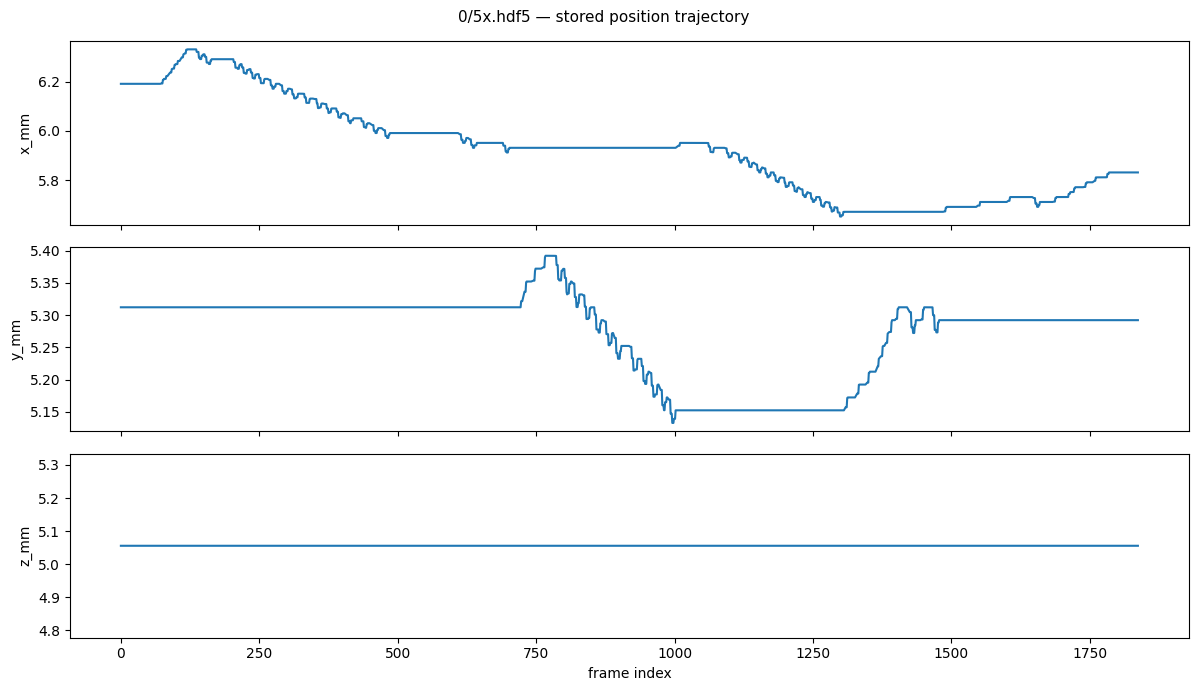

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for i, name in enumerate(['x_mm', 'y_mm', 'z_mm']):
    axes[i].plot(preview_xyz[:, i])
    axes[i].set_ylabel(name)
axes[-1].set_xlabel('frame index')
plt.suptitle(f'{PREVIEW_PATH} — stored position trajectory', fontsize=11)
plt.tight_layout()
plt.show()